# Logistic Regression on Win Column

This notebook will build and train a logistic regression model to classify each match into win/loss. We will do this on three versions of our dataset. One will be trained on the usual dataset, one on just the odds, and one on the dataset without odds. The reason we will do this is to investigate the effect that the odds columns have on prediction. Since these are win probabilities given by bookmakers, they are a very good prediction of who will win the match. They already include much of the information given by the other columns in the dataset, since this is publicly available information and bookmaker models would have taken exactly this information into account when producing the odds. Hence, it may be the case that odds are extremely good predictor of win/loss, and all other columns are redundant. On the other hand, it may be the case that the other columns are able to give a good prediction of the gap between the true win probability and the bookmaker-predicted win probability. This is what we will explore with the different datasets. Throughout, we will also compare the performance of the models against the baseline models we computed in the EDA notebook.

## 1. Preparing the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

sns.set_style("whitegrid")

df_full = pd.read_csv("../Data/full_data_enc.csv")
df_odds = pd.read_csv("../Data/odds_data_enc.csv")
df_nodds = pd.read_csv("../Data/nodds_data_enc.csv")


df_full.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age_c,age_c_sq,is_outdoor,...,Masters Cup,Clay,Grass,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,417,97,5.00,1170,28,1.14,0,-9.817933,96.391807,1,...,0,1,0,1,0,0,0,0,0,0
1,440,97,3.50,1385,18,1.28,0,-9.765914,95.373072,1,...,0,0,0,0,0,0,0,0,0,0
2,431,97,2.50,825,43,1.50,1,-9.724846,94.572630,1,...,0,0,0,0,0,0,0,0,0,0
3,431,97,3.50,1230,24,1.28,1,-9.716632,94.412946,1,...,0,0,0,1,0,0,0,0,0,0
4,431,97,2.75,770,48,1.39,0,-9.711157,94.306565,1,...,0,0,0,0,1,0,0,0,0,0


In [2]:
# Train test split
df_full_train, df_full_test = chrono_split_df(df_full, 0.8)
df_odds_train, df_odds_test = chrono_split_df(df_odds, 0.8)
df_nodds_train, df_nodds_test = chrono_split_df(df_nodds, 0.8)

## 2. Logistic Regression Model / Functions

Here, we will define all of the functions we require to produce our logistic regression model.

In [3]:
def stable_sigmoid(x):
    

    return np.where(x >= 0, 1. / ( 1. + np.exp(-x)), np.exp(x) / ( 1. + np.exp(x) ))

In [4]:
def binary_cross_entrop(y_true, probs, eps=1e-7):

    """
        Computes the binary cross entrop given a vector of true binary labels and a vector of
        probability predictions
    """

    probs = np.clip(probs, eps, 1-eps)
    return - np.mean(y_true * np.log(probs) + (1 - y_true) * (np.log(1 - probs)))

In [5]:
def bce_grad(X, y_true, probs):

    """
        Computes the gradient of the binary cross-entropy with respect to theta.
    """

    return (1 / X.shape[0]) * X.T @ (probs - y_true)

In [6]:
def gradient_descent(X, y, lr=1e-3, iter=10000, thresh=1e-7):

    """
        This is a gradient descent training loop for logistic regression.
    """

    # Initialise coefficients, probabilities vector and loss array
    theta = np.ones((X.shape[1], 1))
    losses = []

    # Begin descent loop
    for i in range(iter):

        # Calculate probabilities
        z = (X @ theta).reshape(-1, 1)
        probs = stable_sigmoid(z)

        # Calculate binary cross entropy and gradient
        loss = binary_cross_entrop(y, probs)
        losses.append(float(loss))
        grad = bce_grad(X, y, probs)

        # Update theta
        theta_new = theta - lr * grad

        # Check for early convergence
        if np.linalg.norm(grad) <= thresh:
            print(fr"We have reached early convergence on iteration {i+1}.")
            return theta_new, losses

        # Update theta
        theta = theta_new

    print(fr"Reached max iterations.")
    print(f"Final gradient norm: {np.linalg.norm(bce_grad(X, y, probs)):.2e}")
    
    return theta, losses

In [7]:
def hard_thresh(probs):

    """
        Calculate the 1/0 prediction from the probability scores
    """

    return np.where(probs >= 0.5, 1, 0)

In [8]:
def accuracy(y_true, y_hat):

    """
        Calculates the accuracy of the model. y_true are the true labels and y_hat are the hard
        thresholded probabilities.
    """

    return np.mean(y_true == y_hat) * 100

## 3. Odds Dataset

We begin with a dataset containing only the odds columns, and evaluate how well it predicts Djokovic's win probability.

In [9]:
df_odds_train.head()

,dj_odds,opp_odds,dj_win
0,5.00,1.14,0
1,3.50,1.28,0
2,2.50,1.50,1
3,3.50,1.28,1
4,2.75,1.39,0


In [10]:
# Separating target from predictors
y_train, y_test = df_odds_train['dj_win'].to_numpy().reshape(-1, 1), df_odds_test['dj_win'].to_numpy().reshape(-1, 1)
X_train, X_test = df_odds_train[['dj_odds', 'opp_odds']].to_numpy(), df_odds_test[['dj_odds', 'opp_odds']].to_numpy()

In [11]:
# Standardise and augment prediction matrix
X_train_std = standardise_cols(X_train, np.arange(0, X_train.shape[1]))
X_test_std = standardise_cols(X_test, np.arange(0, X_test.shape[1]), scaler=X_train)

X_train_sa = np.concatenate([np.ones((X_train_std.shape[0], 1)), X_train_std], axis=1)
X_test_sa = np.concatenate([np.ones((X_test_std.shape[0], 1)), X_test_std], axis=1)

Now that our data is fully separated, standardised, and augmented, we can train our model.

In [12]:
# Train the model
theta, losses = gradient_descent(X_train_sa, y_train, iter=300000)

Reached max iterations.
Final gradient norm: 1.24e-04


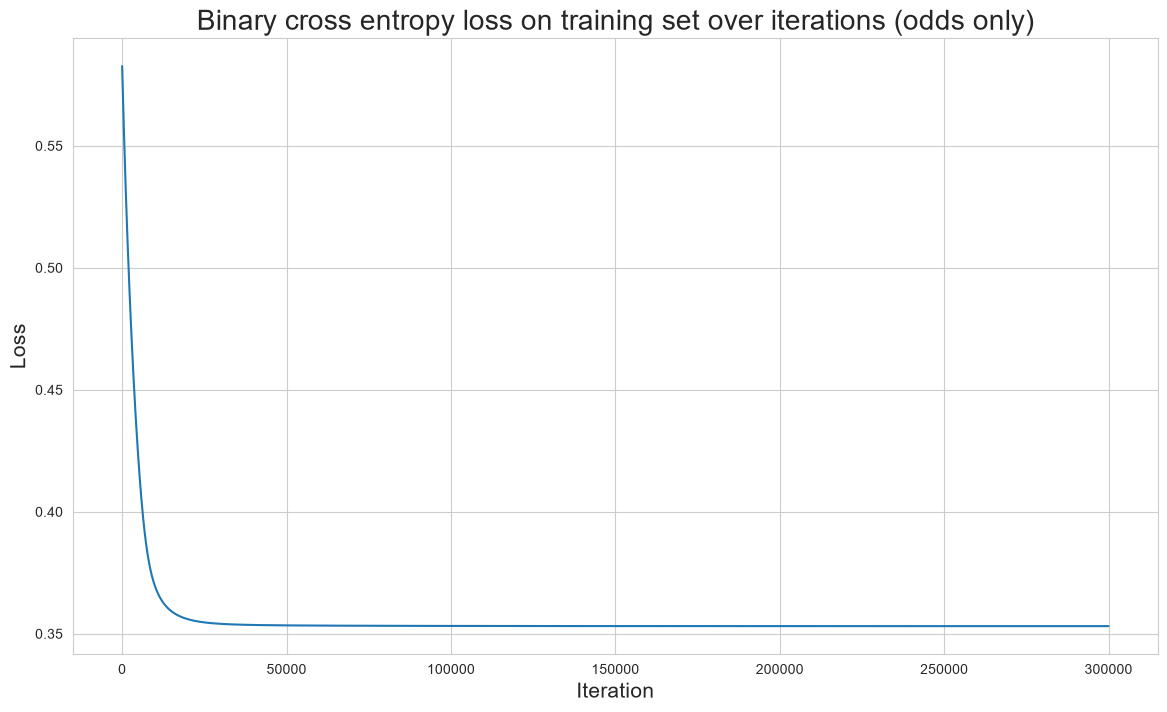

In [13]:
# Plotting the training binary cross entropy (loss) curve
plt.figure(figsize=(14, 8))
plt.plot(losses)
plt.xlabel("Iteration", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Binary cross entropy loss on training set over iterations"
            " (odds only)", fontsize=20)
plt.show()


In [14]:
# Test set loss and accuracy
z_test = X_test_sa @ theta
probs_test = stable_sigmoid(z_test)
bce = binary_cross_entrop(y_test, probs_test)
y_hat = hard_thresh(probs_test)
acc = accuracy(y_test, y_hat)
print("Odds Logistic Regression Test Loss and Accuracy")
print("-"*50)
print(f"Train Loss: {losses[-1]:.4f}")
print(f"Test Loss: {bce:.4f}")
print(f"Accuracy: {acc:.2f}%")

Odds Logistic Regression Test Loss and Accuracy
--------------------------------------------------
Train Loss: 0.3531
Test Loss: 0.3870
Accuracy: 85.48%


The above shows that the logistic regression trained on the odds-only data performs better than the baseline model, indicating that it is learning some signal related to both wins and losses and is actually attempting to distinguish the two.

## 4. No Odds Dataset

We will now train a logistic regression model on the same train / test split of the dataset using all columns apart from the odds columns. This will be informative to see whether the bookmaker predictions will be better indicators of win/loss than what we can predict using our chosen variables.

In [15]:
df_nodds_train.head()

,dj_pts,dj_rank,opp_pts,opp_rank,dj_win,age_c,age_c_sq,is_outdoor,is_five_sets,5SMA,...,Masters Cup,Clay,Grass,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,417,97,1170,28,0,-9.817933,96.391807,1,0,1.000000,...,0,1,0,1,0,0,0,0,0,0
1,440,97,1385,18,0,-9.765914,95.373072,1,0,0.500000,...,0,0,0,0,0,0,0,0,0,0
2,431,97,825,43,1,-9.724846,94.572630,1,1,0.333333,...,0,0,0,0,0,0,0,0,0,0
3,431,97,1230,24,1,-9.716632,94.412946,1,1,0.500000,...,0,0,0,1,0,0,0,0,0,0
4,431,97,770,48,0,-9.711157,94.306565,1,1,0.600000,...,0,0,0,0,1,0,0,0,0,0


In [16]:
# Separate target from predictors
X_train, X_test = df_nodds_train.drop(columns='dj_win'), df_nodds_test.drop(columns='dj_win')

In [17]:
# Now convert to numpy arrays, standardise, and augment
X_nodds_train_std = standardise_cols(X_train.to_numpy(), np.arange(0, X_train.shape[1]))
X_nodds_test_std = standardise_cols(X_test.to_numpy(), np.arange(0, X_test.shape[1]), scaler=X_train.to_numpy())

X_nodds_train_sa = np.concatenate([np.ones((X_nodds_train_std.shape[0], 1)), X_nodds_train_std], axis=1)
X_nodds_test_sa = np.concatenate([np.ones((X_nodds_test_std.shape[0], 1)), X_nodds_test_std], axis=1)

In [18]:
theta_nodds, losses_nodds = gradient_descent(X_nodds_train_sa, y_train, iter=300000)

Reached max iterations.
Final gradient norm: 2.97e-03


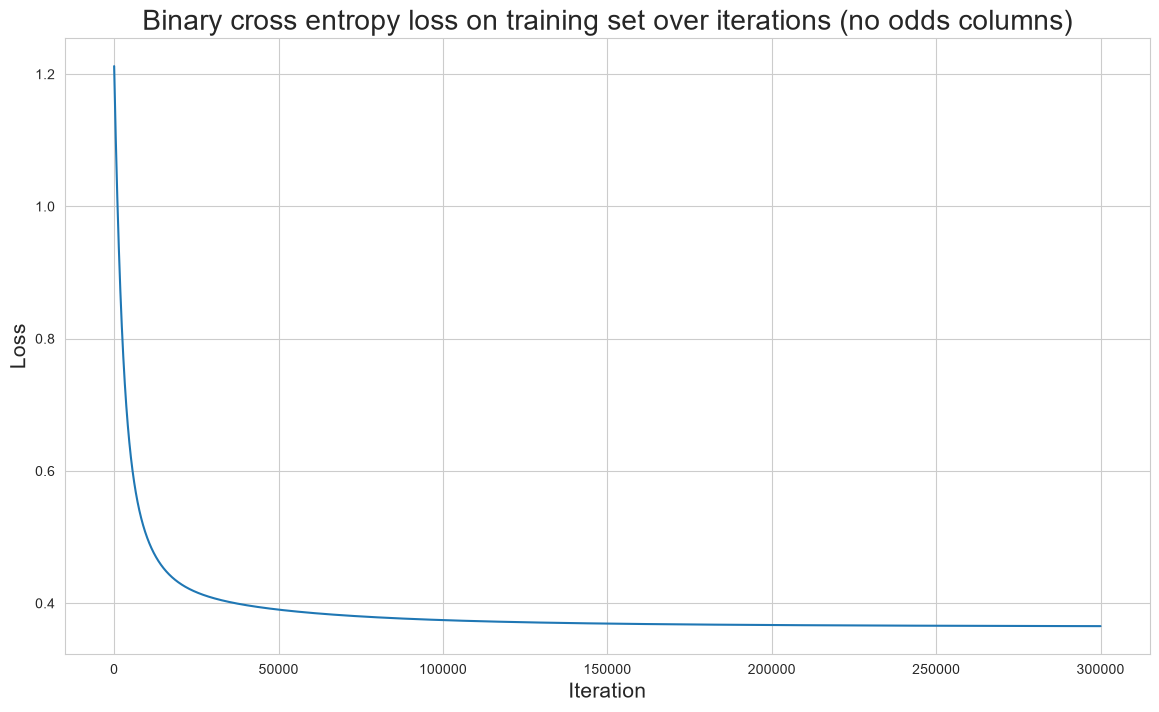

In [19]:
# Plotting the training binary cross entropy (loss) curve
plt.figure(figsize=(14, 8))
plt.plot(losses_nodds)
plt.xlabel("Iteration", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Binary cross entropy loss on training set over iterations"
            " (no odds columns)", fontsize=20)
plt.show()


In [20]:
# Test set loss and accuracy
z_test_nodds = X_nodds_test_sa @ theta_nodds
probs_nodds_test = stable_sigmoid(z_test_nodds)
bce = binary_cross_entrop(y_test, probs_nodds_test)
y_hat_nodds = hard_thresh(probs_nodds_test)
acc = accuracy(y_test, y_hat_nodds)
print("Non-Odds Logistic Regression Test Loss and Accuracy")
print("-"*50)
print(f"Train Loss: {losses_nodds[-1]:.4f}")
print(f"Test Loss: {bce:.4f}")
print(f"Accuracy: {acc:.2f}%")

Non-Odds Logistic Regression Test Loss and Accuracy
--------------------------------------------------
Train Loss: 0.3654
Test Loss: 0.4264
Accuracy: 82.66%


As we can see, the binary cross entropy on both the training set and the test set is worse for the model with no odds columns than the model with just odds columns. This indicates that the odds columns on their own are a better predictor of the win probabilities than all of the other columns all together. The binary cross entropy on both the training and test set it better than the baseline BCEs computed in the EDA notebook. This indicates that the model is becoming more confident in its correct predictions, and/or less confident in its wrong predictions. However, the accuracy is lower than the accuracy for the baseline model ($82.66\%$ vs $83.87\%$). This is an interesting development, since the BCE is better but accuracy worse. One way this can happen is if some borderline probabilities have been shifted over to the wrong side, meaning these predictions will worsen the accuracy, however overall there has been a greater shift of correct probabilities further towards the extreme points which outweigh the shifts in the wrong direction given by the borderline probabilities.

## 5. Entire Dataset

We will now investigate the performance of logistic regression on the entire dataset. This will show us whether the columns we have chosen apart from odds can help explain the gap between market-implied probabilities and the true win probabilities.

In [21]:
# Separate target from predictors
X_train, X_test = df_full_train.drop(columns='dj_win'), df_full_test.drop(columns='dj_win')

In [22]:
# Now convert to numpy arrays, standardise and augment
X_full_train_std = standardise_cols(X_train.to_numpy(), np.arange(0, X_train.shape[1]))
X_full_test_std = standardise_cols(X_test.to_numpy(), np.arange(0, X_test.shape[1]), scaler=X_train.to_numpy())

X_full_train_sa = np.concatenate([np.ones((X_full_train_std.shape[0], 1)), X_full_train_std], axis=1)
X_full_test_sa = np.concatenate([np.ones((X_full_test_std.shape[0], 1)), X_full_test_std], axis=1)

In [23]:
theta_full, losses_full = gradient_descent(X_full_train_sa, y_train, iter=300000)

Reached max iterations.
Final gradient norm: 3.15e-03


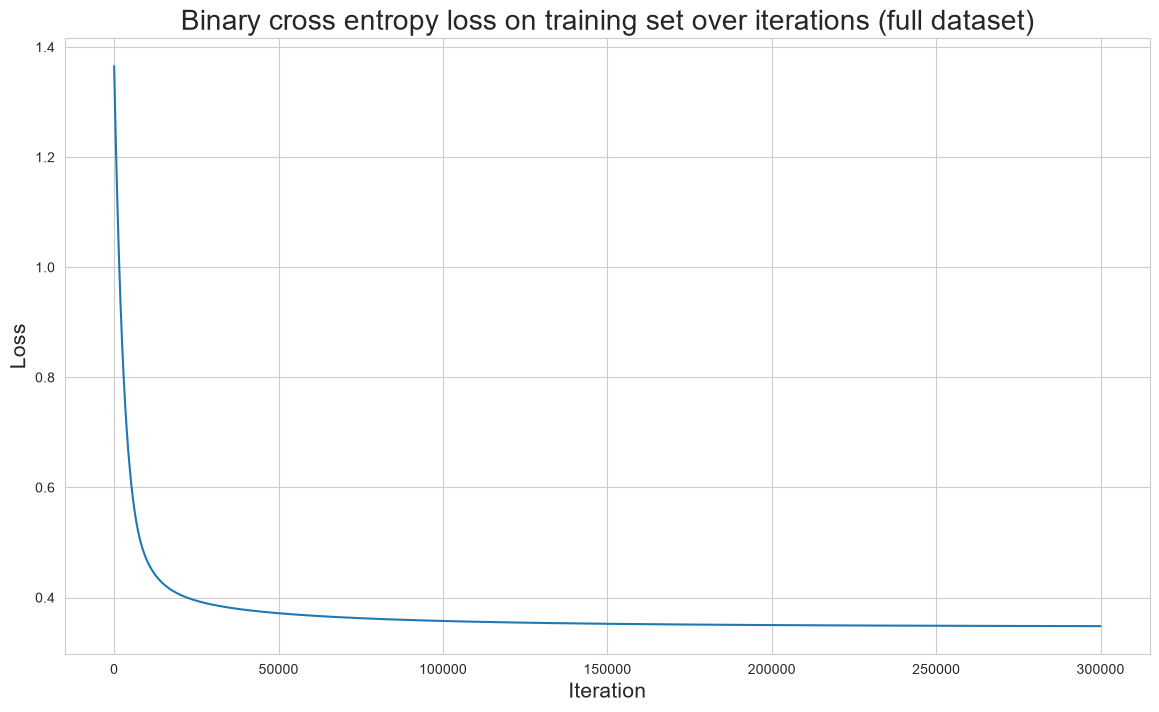

In [24]:
# Plotting the training binary cross entropy (loss) curve
plt.figure(figsize=(14, 8))
plt.plot(losses_full)
plt.xlabel("Iteration", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Binary cross entropy loss on training set over iterations"
            " (full dataset)", fontsize=20)
plt.show()


In [25]:
# Test set loss and accuracy
z_test_full = X_full_test_sa @ theta_full
probs_full_test = stable_sigmoid(z_test_full)
bce = binary_cross_entrop(y_test, probs_full_test)
y_hat_full = hard_thresh(probs_full_test)
acc = accuracy(y_test, y_hat_full)
print("Full Logistic Regression Test Loss and Accuracy")
print("-"*50)
print(f"Train Loss: {losses_full[-1]:.4f}")
print(f"Test Loss: {bce:.4f}")
print(f"Accuracy: {acc:.2f}%")

Full Logistic Regression Test Loss and Accuracy
--------------------------------------------------
Train Loss: 0.3480
Test Loss: 0.4102
Accuracy: 84.68%


The full dataset model performs better on both the training and test set than the no-odds model, and also has a better accuracy, increasing by $\approx 2$ percentage points. This indicates the strong predictive power of the odds.

However, the full dataset model actually performs worse than the odds-only model. This can be because the extra features introduce noise, essentially confusing the model, and not allowing it to draw as sharp boundaries as the odds themselves do.

## 6. Discussion

#### Results Summary

| Model (dataset)        | Train BCE | Test BCE | Test accuracy |
|------------------------|-----------|----------|---------------|
| Odds only              | 0.3531    | 0.3870   | 85.48%        |
| No odds                | 0.3654    | 0.4264   | 82.66%        |
| Full (all features)    | 0.3480    | 0.4102   | 84.68%        |

*Base-rate baseline (predict win rate ≈0.84 for every match): test BCE ≈ 0.4419. Test accuracy for a model predicting win every time ≈ 83.87%, as found in EDA notebook.*

The odds-only model outperforms the no odds model in all of the metrics, with lower BCEs and higher accuracy. This indicates that in a logistic regression, our chosen features do not encode more signal than the odds themselves. We can also see from the results summary that the additional features outside of the odds column do not add any significant additional signal that the odds don't already provide. In fact, the additional features actually make the performance worse, decreasing the accuracy and increasing test BCE in the full model compared to the odds only model. This can be due to the additional features adding noise which muddies the signal, and makes it more difficult for the model to distinguish wins and losses. Since the training BCE is slightly lower, but the test BCE is higher, this also points towards some overfitting that is introduced by adding these additional features.

In relation to the baselines, the odds only model clearly does better than both the baseline BCE and accuracy. The no odds model has a slightly better BCE than the win rate baseline, but its accuracy is worse than the always-win predictor. However, the improvement in BCE indicates that it is shifting some of the probabilities in the correct direction, just that there are some shifts of probabilities over the $0.5$ threshold in the wrong direction that are outweighed by larger probability shifts in the correct direction. The full model also does better than both baselines.

Overall, there is no improvement in model performance through the addition of our features, and in fact they actually negatively affect the performance of our logistic regression. Some different and more informative features need to be engineered in order to beat the signal that the odds produce.